In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [7]:
#Loading the dataset
df = pd.read_csv("/content/Wholesale customers data.csv")

print(df.head())
print(df.info())


   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen  

In [8]:
#Checking for null-values
print(df.isnull().sum())


Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


In [9]:
#Removing the irrelevant columns
df = df.drop(columns=['Channel', 'Region'])
print(df.head())


   Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669  9656     7561     214              2674        1338
1   7057  9810     9568    1762              3293        1776
2   6353  8808     7684    2405              3516        7844
3  13265  1196     4221    6404               507        1788
4  22615  5410     7198    3915              1777        5185


In [10]:
# Selecting relevant columns for K-means
X = df[['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]


In [11]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


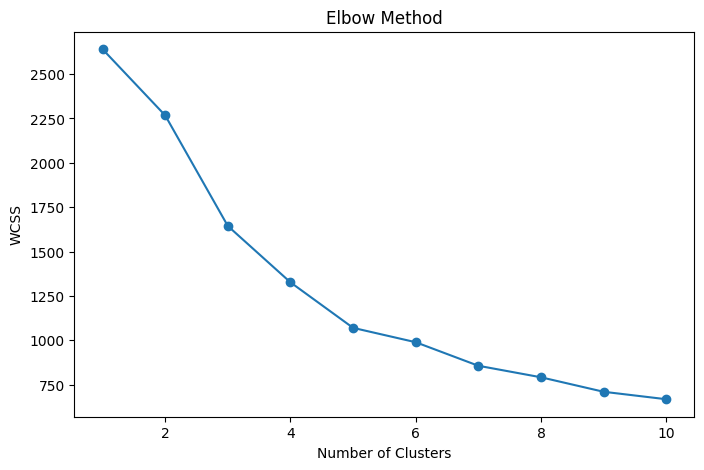

In [12]:
# Elbow method to find Optimal K
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [13]:
# Applying K-means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
print(df.head())


   Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen  Cluster
0  12669  9656     7561     214              2674        1338        0
1   7057  9810     9568    1762              3293        1776        0
2   6353  8808     7684    2405              3516        7844        0
3  13265  1196     4221    6404               507        1788        0
4  22615  5410     7198    3915              1777        5185        1


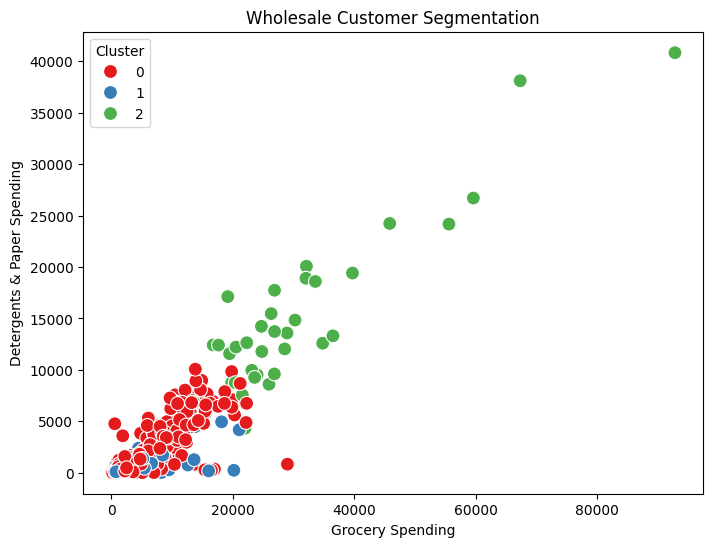

In [14]:
# Visualizing the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df['Grocery'],
    y=df['Detergents_Paper'],
    hue=df['Cluster'],
    palette='Set1',
    s=100 )
plt.title("Wholesale Customer Segmentation")
plt.xlabel("Grocery Spending")
plt.ylabel("Detergents & Paper Spending")
plt.show()
